# Coupled two-node mean-field brain network analysis

In [91]:
import os
import sys
import json
import time
import random
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

from scipy import signal, linalg
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from tqdm import  tqdm

sys.path.insert(1, 'utils')
from utils.utils import *
from plotUtils import *
from utils.mUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 18})

In [92]:
COLOR_MAP = {
                'mediumblue': "Unstable Node",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [ ]:
def plot_trajectory(ts, init_points, parameters, fig_size=(10, 10), **results):
    dim_labels = [r'$u_{\rm e}^1$', r'$u_{\rm i}^1$', r'$u_{\rm e}^2$', r'$u_{\rm i}^2$']
    fp = results.get('fps')

    fig, axes = plt.subplots(1, 2, figsize=fig_size)

    # Plotting the vector field in the state space (E, I)
    axes[0].set_ylabel(dim_labels[0], rotation=0, labelpad=15, fontsize=20);
    axes[0].set_xlabel(dim_labels[1], fontsize=20)

    axes[1].set_ylabel(f"{dim_labels[2]} - {dim_labels[0]}", labelpad=15, fontsize=20);
    axes[1].set_xlabel(f"{dim_labels[3]} - {dim_labels[1]}", fontsize=20)

    x0_, x1_, x2_, x3_ = init_points

    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
        kts = ts[k, :, :]

        # Plot the solution in the state space
        axes[0].plot(kts[1, :], kts[0, :], 'b--', alpha=.4)
        axes[0].scatter(y0[1], y0[0], marker='.', c='k', s=200, label=f"{dim_labels[0]} = {y0[0]:.3f}, {dim_labels[1]} = {y0[1]:.3f}")

        axes[1].plot(kts[3, :] - kts[1, :], kts[2, :] - kts[0, :], 'b--', alpha=.4)
        axes[1].scatter(y0[3] - y0[1], y0[2] - y0[0], marker='.', c='k', s=200,
                           label=f"{dim_labels[2]} - {dim_labels[0]} = {y0[2] - y0[0]:.3f}, {dim_labels[3]} - {dim_labels[1]} = {y0[3] - y0[1]:.3f}")
    
    # Plot the fixed points identified
    if len(fp) > 0:
        fp = fp.T
        eval_dict = calc_jacobian(fp, **parameters)
        print(eval_dict)
        colors = eval_dict['types']
        for i in range(results['n_fps']):
            axes[0].scatter(fp[i, 1], fp[i, 0], marker='*', c=colors[i], s=200, label=f"Fixed points")
            axes[1].scatter(fp[i, 3] - fp[i, 1], fp[i, 2] - fp[i, 0], marker='*', c=colors[i], s=200, label=f"Fixed points")
        
    for pos in ['right', 'top', 'bottom', 'left']:
        axes[0].spines[pos].set_visible(False)
        axes[1].spines[pos].set_visible(False)

    fig.align_ylabels()
    fig.tight_layout()
    plt.show()
    return

In [ ]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5/ params['gamma']
grid_res = 100
n_trials = 5

# time vector
params['dt'] = 0.005
params['D0'] = 0.000 / (params['gamma'] * params['gamma'])
T = params['T'] = int(params['T'] / (params['dt'] * 10))
time_ = np.arange(0, T)

t_start = int(500 / (params['dt'] * 10))
t_end = T

In [95]:
# Initialization points
np.random.seed(0)
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

In [ ]:
i_min = 0; i_max = 0.5; i_steps = 500
i_values = i_min + np.arange(0, i_steps) / (i_steps - 1) * (i_max - i_min)

sMin = 2.5; sMax = 16.5; sSteps = 25
sVals = sMin + np.arange(0, sSteps) / (sSteps - 1) * (sMax - sMin)

In [99]:
params['sig_e1'] = params['sig_e2'] = 2.5
params['sig_i1'] = params['sig_i2'] = 3.92
params['K'] = 0.2
params['i_e1'] = 31.25 + params['i_e2'] #0.25 / params['gamma']

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

results = calc_fixed_points(
                    minval = minval,
                    maxval = maxval,
                    grid_res=75,
                    n_init=20,
                    cal_grad=False,
                    **params
            )

/home/kalana/MAScResearch/network_modeling/two_node_system/utils/utils.py:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


In [100]:
lyapunov_1 = np.zeros((T - t_start - 1))
for j in range(n_trials):
    diff_1 = np.abs(np.diff(u[j, 0, t_start:])) / (params['dt'] * 10)
    lyapunov_1 += 1 / n_trials * np.log(diff_1)

In [101]:
tspan = np.arange(0, T) * (params['dt'] * 10)

Text(0.5, 1.0, '$\\overline{\\ell}_e = $1.27')

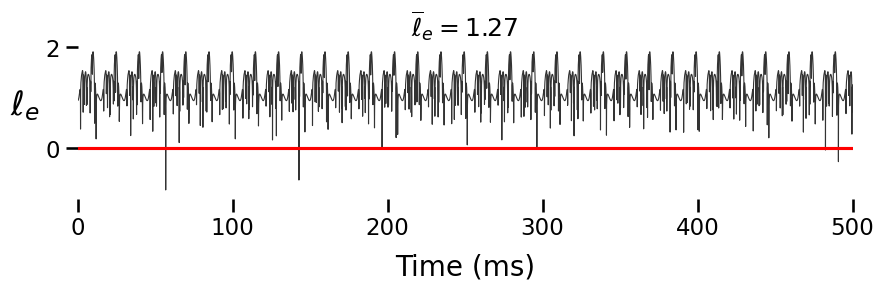

In [102]:
plt.figure(figsize=(10, 2))
minValue = np.min(lyapunov_1[lyapunov_1 != -np.inf]) if len(lyapunov_1[lyapunov_1 != -np.inf]) != 0 else -10
lyapunov_1[lyapunov_1 == -np.inf] = minValue

plt.plot(tspan[:-t_start-1], lyapunov_1, 'k', alpha=0.8, linewidth=.8)
plt.axhline(y=0.0, color='r', linestyle='-')
plt.xlabel(r'Time (ms)', fontsize=20, labelpad=10); plt.ylabel(r"$\ell_e$", rotation=0, labelpad=15, fontsize=24)
plt.xlim([0, 500])

for pos in ["right", "top", "left", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    plt.gca().spines[pos].set_visible(False)

plt.title(r"$\overline{\ell}_e = $" + f"{np.mean(lyapunov_1):.2f}", fontsize=18)

/tmp/ipykernel_565985/637647470.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


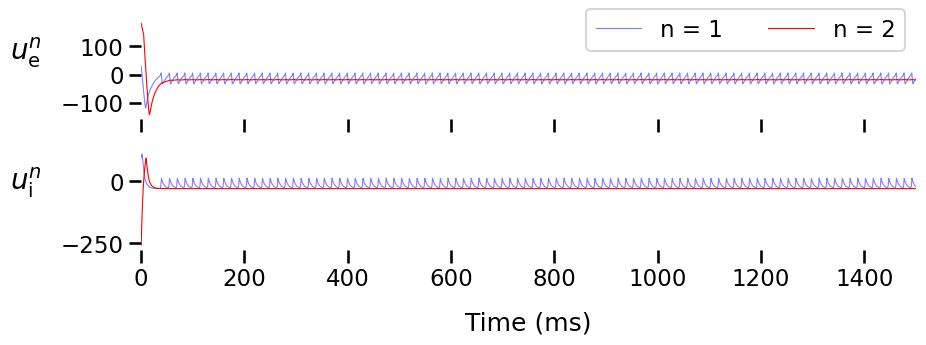

In [103]:
title_str = r'$K$ = ' + f"{params.get('K'):.2f}" # + r'$I_{e}^1$ = ' + f"{params.get('i_e1') - params.get('i_e2'):.3f}mV, "
sub_title_str = r'$\sigma$ = ' + \
                f"{params.get('sig_e1'):.3f}"

fig, axis = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={"hspace":0.3})
fig.subplots_adjust(hspace=.15)

axis[0].plot(tspan, u[0, 0, :], 'b', linewidth=.8, alpha=0.5)
axis[0].plot(tspan, u[0, 2, :], 'r', linewidth=.8)
axis[0].yaxis.set_label_position("left")
axis[0].set_ylabel(r'$u_{\rm e}^n$', rotation=0, labelpad=25, fontsize=20);

axis[1].plot(tspan, u[0, 1, :], 'b', linewidth=.8,  label='n = 1', alpha=0.5)
axis[1].plot(tspan, u[0, 3, :], 'r', linewidth=.8, label='n = 2')
axis[1].yaxis.set_label_position("left")
axis[1].set_xlim([0, 1500])
axis[1].set_ylabel(r'$u_{\rm i}^n$', rotation=0, labelpad=25, fontsize=20)
axis[1].set_xlabel(r'Time (ms)', labelpad=15, fontsize=18)

for pos in ["right", "left", "top", "bottom"]:
    axis[0].spines[pos].set_visible(False)
    axis[1].spines[pos].set_visible(False)
fig.legend(ncols=2, bbox_to_anchor = (0.9, .95))
plt.tight_layout()


/tmp/ipykernel_565985/571365776.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


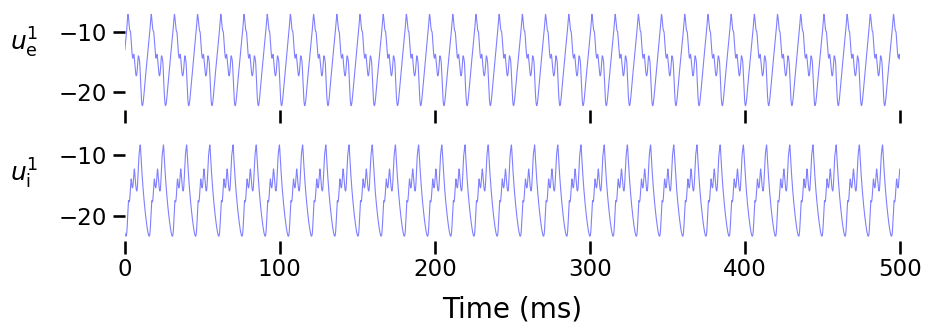

In [ ]:
title_str = r'$K$ = ' + f"{params.get('K'):.2f}" # + r'$I_{e}^1$ = ' + f"{params.get('i_e1') - params.get('i_e2'):.3f}mV, "
sub_title_str = r'$\sigma$ = ' + \
                f"{params.get('sig_e1'):.3f}"

fig, axis = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={"hspace":0.3})
fig.subplots_adjust(hspace=.15)

axis[0].plot(tspan[: -t_start], np.mean(u[:, 0, t_start:], axis=0), 'b', linewidth=.8, alpha=0.5)
# axis[0].plot(tspan[: -t_start + t_end], np.mean(u[:, 2, t_start:t_end], axis=0), 'r', linewidth=.8)
axis[0].yaxis.set_label_position("left")
axis[0].set_ylabel(r'$u_{\rm e}^1$', rotation=0, labelpad=25, fontsize=18);

axis[1].plot(tspan[: -t_start], np.mean(u[:, 1, t_start:], axis=0), 'b', linewidth=.8,  label='n = 1', alpha=0.5)
# axis[1].plot(tspan[: -t_start + t_end], np.mean(u[:, 3, t_start:t_end], axis=0), 'r', linewidth=.8, label='n = 2')
axis[1].yaxis.set_label_position("left")
axis[1].set_ylabel(r'$u_{\rm i}^1$', rotation=0, labelpad=25, fontsize=18)
axis[1].set_xticks(np.arange(0, tspan[-t_start + t_end], 100))
axis[1].set_xlabel(r'Time (ms)', fontsize=20, labelpad=10)
axis[1].set_xlim(0, 500)

for pos in ["right", "left", "top", "bottom"]:
    axis[0].spines[pos].set_visible(False)
    axis[1].spines[pos].set_visible(False)
fig.align_ylabels()
plt.tight_layout()


In [119]:
beta = params['beta']
gamma = params['gamma']
theta = params['theta']
@nb.njit()
def sigmoidfn(x):
    return 1 / (1 + np.exp(-beta * (x - theta)))

@nb.njit()
def Ffn(x, sig):
    vmin = -1 / gamma; vmax = 1 / gamma; nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)
    normal_vals = np.exp(-v ** 2 / (2 * sig ** 2)) / np.sqrt(2 * np.pi * sig ** 2)

    sum = 0
    
    for i in range(nsteps):
        sum = sum +  dv * sigmoidfn(x + v[i]) * normal_vals[i]
    return sum

@nb.njit()
def Fu_calc(x, sigma):
    nSamples = x.shape[0]
    Fu_inh = np.zeros(nSamples)

    for t in range(nSamples):
        Fu_inh[t] += Ffn(x[t], sigma)

    return Fu_inh

/home/kalana/MAScResearch/network_modeling/two_node_system/utils/utils.py:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * (x - thresh)))


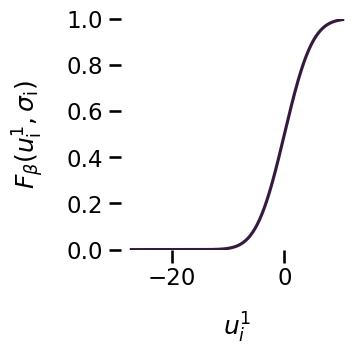

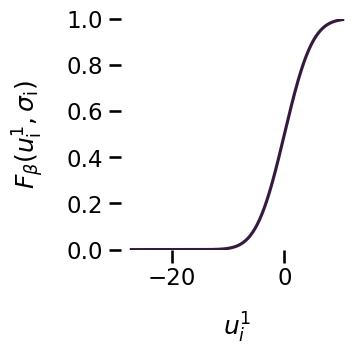

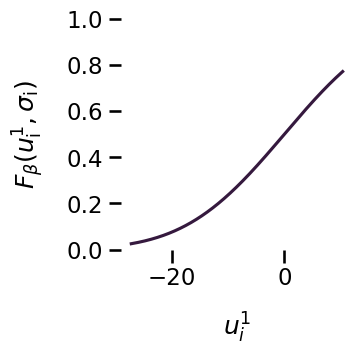

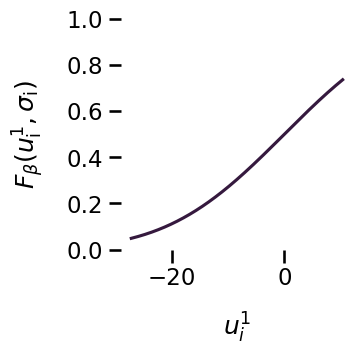

In [121]:
params['sig_e1'] = params['sig_e2'] = 2.5
params['sig_i1'] = params['sig_i2'] = 3.92
params['K'] = 0.2
params['i_e1'] = 31.25 + params['i_e2'] #0.25 / params['gamma']

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

uEnh_unique, idE_unique = np.unique(u[:, 0, t_start:].flatten(), return_index=True)
uInh_unique, idI_unique = np.unique(u[:, 1, t_start:].flatten(), return_index=True)

Fu_inh = Fu_calc(uInh_unique, params['sig_i1'])
Fu_exc = Fu_calc(uEnh_unique, params['sig_e1'])


plt.figure(figsize=(3, 3))
plt.plot(uInh_unique, Fu_inh)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$F_{\beta}(u_{\mathrm{i}}^1, \sigma_{\mathrm{i}})$", labelpad=15, fontsize=18)
plt.ylim(0, 1)
plt.xlabel(r"$u_i^1$", labelpad=15, fontsize=18)

plt.figure(figsize=(3, 3))
plt.plot(uInh_unique, Fu_inh)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$F_{\beta}(u_{\mathrm{i}}^1, \sigma_{\mathrm{i}})$", labelpad=15, fontsize=18)
plt.ylim(0, 1)
plt.xlabel(r"$u_i^1$", labelpad=15, fontsize=18)

for sig_i in [14, 16.5]:
    Fu_inh = Fu_calc(uInh_unique, sig_i)

    plt.figure(figsize=(3, 3))
    plt.plot(uInh_unique, Fu_inh)

    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)
        plt.gca().spines[pos].set_visible(False)

    plt.ylabel(r"$F_{\beta}(u_{\mathrm{i}}^1, \sigma_{\mathrm{i}})$", labelpad=15, fontsize=18)
    plt.ylim(0, 1)
    plt.xlabel(r"$u_i^1$", labelpad=15, fontsize=18)

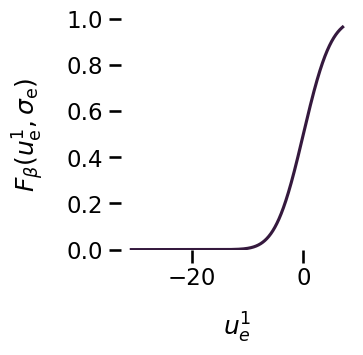

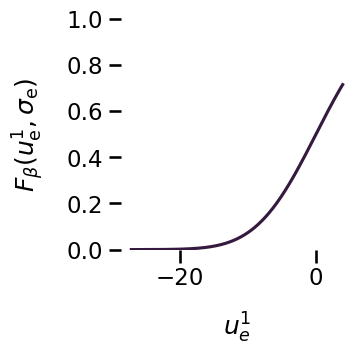

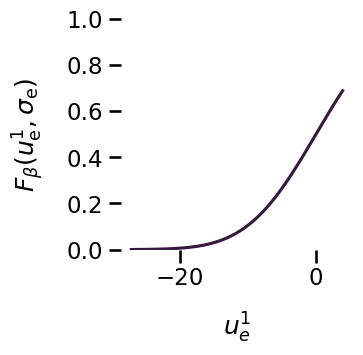

In [124]:
params['sig_e1'] = params['sig_e2'] = 2.5
params['sig_i1'] = params['sig_i2'] = 3.92
params['K'] = 0.8
params['i_e1'] = 31.25 + params['i_e2'] #0.25 / params['gamma']

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

uEnh_unique, idE_unique = np.unique(u[:, 0, t_start:].flatten(), return_index=True)
uInh_unique, idI_unique = np.unique(u[:, 1, t_start:].flatten(), return_index=True)

Fu_inh = Fu_calc(uInh_unique, params['sig_i1'])
Fu_exc = Fu_calc(uEnh_unique, params['sig_e1'])


plt.figure(figsize=(3, 3))
plt.plot(uInh_unique, Fu_inh)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$F_{\beta}(u_{\mathrm{e}}^1, \sigma_{\mathrm{e}})$", labelpad=15, fontsize=18)
plt.ylim(0, 1)
plt.xlabel(r"$u_e^1$", labelpad=15, fontsize=18)

for sig_e in [6.92, 8]:
    Fu_exc = Fu_calc(uEnh_unique, sig_e)

    plt.figure(figsize=(3, 3))
    plt.plot(uEnh_unique, Fu_exc)

    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)
        plt.gca().spines[pos].set_visible(False)

    plt.ylabel(r"$F_{\beta}(u_{\mathrm{e}}^1, \sigma_{\mathrm{e}})$", labelpad=15, fontsize=18)
    plt.ylim(0, 1)
    plt.xlabel(r"$u_e^1$", labelpad=15, fontsize=18)

/home/kalana/MAScResearch/network_modeling/two_node_system/utils/utils.py:221: RuntimeWarning: overflow encountered in square
  return beta * np.exp(-beta * (x - theta)) / ((1 + np.exp(-beta * (x - theta))) ** 2)


{'eigvals': [array([-0.85695677+7.33958555j, -0.85695677-7.33958555j,
       -0.53572566+0.j        , -1.99998812+0.j        ])], 'types': ['saddlebrown'], 'jacobian': array([[ 7.81927749e-01, -8.55275372e+00,  8.00000000e-01,
         0.00000000e+00],
       [ 6.68222906e+00, -2.47313106e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 8.00000000e-01,  0.00000000e+00, -5.58423401e-01,
        -1.09095266e-05],
       [ 0.00000000e+00,  0.00000000e+00,  1.65591224e+00,
        -2.00000060e+00]])}


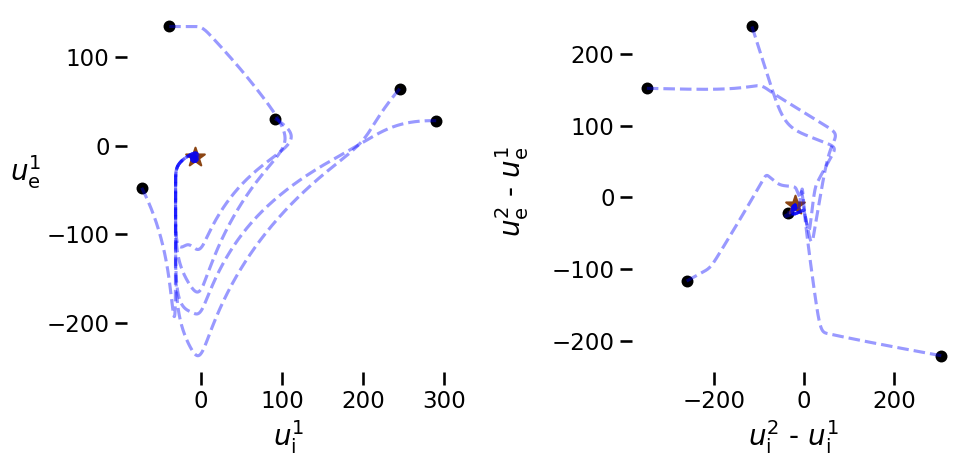

In [194]:
plot_trajectory(ts=u, init_points=[x0_, x1_, x2_, x3_], parameters=params, fig_size=(10, 5), **results)

In [79]:
jac = calc_jacobian(results['fps'].T, **params)['eigvals']

/home/kalana/MAScResearch/network_modeling/two_node_system/utils/utils.py:221: RuntimeWarning: overflow encountered in square
  return beta * np.exp(-beta * (x - theta)) / ((1 + np.exp(-beta * (x - theta))) ** 2)


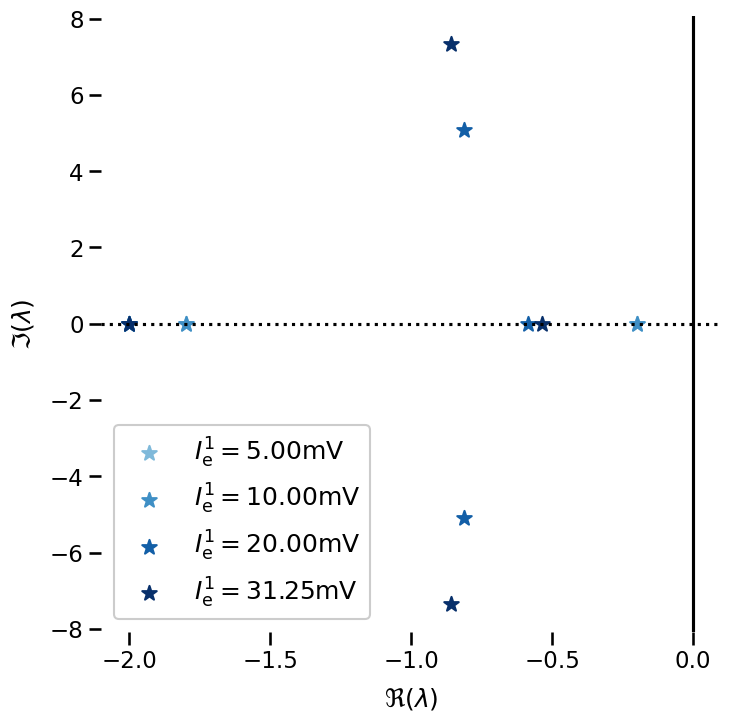

In [197]:
params['sig_e1'] = params['sig_e2'] = 12
params['sig_i1'] = params['sig_i2'] = 5
params['K'] = 0.8

colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.45, 1, 4)))

plt.figure(figsize=(8, 8))
for I in [5, 10, 20, 31.25]:
    params['i_e1'] = I + params['i_e2'] #0.25 / params['gamma']

    results = calc_fixed_points(
                        minval = minval,
                        maxval = maxval,
                        grid_res=75,
                        n_init=20,
                        cal_grad=False,
                        **params
                )
    
    jac = calc_jacobian(results['fps'].T, **params)['eigvals']
    color = next(colorIter)
    for i in range(len(jac)):
        plt.scatter(jac[i].real, jac[i].imag, s=120, color=color, marker='*', label=r'$I_{\rm e}^1 = $' + f"{I:.2f}mV")

plt.axvline(x=0, color='k', linestyle='-')
plt.axhline(y=0, color='k', linestyle=':')
plt.xticks(np.arange(-2, 0.4, 0.5))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
    plt.gca().spines[pos].set_visible(False)

plt.xlabel(r"$\Re(\lambda)$", labelpad=10)
plt.ylabel(r"$\Im(\lambda)$", labelpad=10, )

plt.legend(loc='lower left', facecolor='white', fontsize=18, framealpha=1)
# plt.legend(loc = 'center right', bbox_to_anchor=(1.4, 0.5), edgecolor='white', facecolor='white', fontsize=18, framealpha=0)